# 📓 Notebook 4 — Statistical Analysis
### AirSense AI — Intelligent Urban Air Quality Forecasting & Decision Support System

**Purpose of this notebook**

Notebook 3 gave us visual impressions (e.g. "wind speed looks like it might
relate to PM2.5"). This notebook tests those impressions formally, so that
only **statistically justified** variables move forward into Feature
Engineering (Notebook 5) and Modeling (Notebook 6).

We answer four concrete questions:

1. **Pearson correlation** — linear relationship between each weather
   variable and PM2.5
2. **Spearman correlation** — monotonic (not necessarily linear) relationship
   — catches patterns Pearson might miss
3. **ADF test** — is PM2.5 stationary, or does it have trends/seasonality
   that need to be accounted for before modeling?
4. **Cross-correlation** — does a weather variable predict PM2.5 better at
   some **lag** (e.g. wind speed 3 hours ago) than at the same hour?
5. **Granger causality** — does adding a weather variable's *past* values
   genuinely improve PM2.5 prediction, beyond what PM2.5's own past values
   already tell us?

⚠️ **Correlation ≠ causation.** Granger causality is a statistical test for
predictive usefulness, not a proof of true physical causation — we treat it
as "does this variable help forecast PM2.5" rather than "does this variable
cause PM2.5."

---


## 1. Imports & setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

print("pandas:", pd.__version__, "| scipy loaded | statsmodels loaded")

pandas: 2.3.3 | scipy loaded | statsmodels loaded


## 2. Load the AirSense Feature Cube

Same explicit datetime parsing as Notebook 3 — the `time` column has mixed
UTC offsets from DST transitions, so we parse with `utc=True` first, then
convert, rather than relying on `parse_dates=` (which silently fails on
mixed offsets).

In [2]:
PROJECT_ROOT = Path(r"C:\Users\pc\Desktop\AirSenseAI")
CUBE_PATH = PROJECT_ROOT / "data" / "processed" / "airsense_cube.csv"

print("Cube file:", CUBE_PATH, "| exists:", CUBE_PATH.exists())

Cube file: C:\Users\pc\Desktop\AirSenseAI\data\processed\airsense_cube.csv | exists: True


In [3]:
df = pd.read_csv(CUBE_PATH)
df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_convert('America/New_York')
df = df.sort_values('time').reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (17568, 17)


,time,PM10,PM2.5,O3,NO2,Temperature,Relative Humidity,Wind Speed,Wind Direction,Precipitation,Cloud Cover,Hour,Weekday,Month,Weekend,ISO Week,Season
0,2023-12-31 19:00:00-05:00,27.8,19.3,0,56.8,3.8,65,5.7,235,0.0,65,19,Sunday,12,True,52,Winter
1,2023-12-31 20:00:00-05:00,31.3,21.7,0,55.6,3.8,60,6.0,245,0.0,99,20,Sunday,12,True,52,Winter
2,2023-12-31 21:00:00-05:00,35.5,24.6,0,54.0,3.1,65,6.8,238,0.0,96,21,Sunday,12,True,52,Winter
3,2023-12-31 22:00:00-05:00,40.0,27.8,0,52.5,2.6,68,8.4,245,0.0,73,22,Sunday,12,True,52,Winter
4,2023-12-31 23:00:00-05:00,43.9,30.5,0,51.5,1.9,74,6.3,246,0.0,100,23,Sunday,12,True,52,Winter


## 3. Pearson correlation — linear relationships with PM2.5

Pearson measures **linear** correlation: does PM2.5 move up/down in a
straight-line relationship with each weather variable? Ranges from -1
(perfect negative) to +1 (perfect positive); near 0 means no linear
relationship.

In [4]:
weather_vars = ['Temperature', 'Relative Humidity', 'Wind Speed',
                'Wind Direction', 'Precipitation', 'Cloud Cover']

pearson_results = []
for var in weather_vars:
    r, p = pearsonr(df[var], df['PM2.5'])
    pearson_results.append({'Variable': var, 'Pearson r': round(r, 4), 'p-value': round(p, 6)})

pearson_df = pd.DataFrame(pearson_results).sort_values('Pearson r', key=abs, ascending=False)
pearson_df

,Variable,Pearson r,p-value
2,Wind Speed,-0.4702,0.000000
1,Relative Humidity,0.3098,0.000000
0,Temperature,0.1339,0.000000
3,Wind Direction,-0.1295,0.000000
5,Cloud Cover,0.1066,0.000000
4,Precipitation,-0.0049,0.518348


**How to read this:** a `p-value` below 0.05 means the correlation is
statistically significant (unlikely to be due to chance, given ~17,500
data points). The `Pearson r` magnitude (regardless of sign) tells you
correlation strength: >0.5 strong, 0.3–0.5 moderate, <0.3 weak.

**Observation:** _(fill this in after running the cell above)_
Note which weather variables show the strongest significant linear
correlation with PM2.5, and whether any show no significant relationship at
all — those become candidates for exclusion later.

## 4. Spearman correlation — monotonic relationships

Spearman doesn't require a straight-line relationship — just that as one
variable increases, the other consistently increases or decreases (even if
the relationship curves). This can reveal relationships Pearson misses.

In [5]:
spearman_results = []
for var in weather_vars:
    rho, p = spearmanr(df[var], df['PM2.5'])
    spearman_results.append({'Variable': var, 'Spearman rho': round(rho, 4), 'p-value': round(p, 6)})

spearman_df = pd.DataFrame(spearman_results).sort_values('Spearman rho', key=abs, ascending=False)
spearman_df

,Variable,Spearman rho,p-value
2,Wind Speed,-0.5358,0.000000
1,Relative Humidity,0.3467,0.000000
3,Wind Direction,-0.2117,0.000000
0,Temperature,0.2080,0.000000
5,Cloud Cover,0.1362,0.000000
4,Precipitation,0.0250,0.000907


**Observation:** _(fill this in after running the cell above)_
Compare against the Pearson results above. If a variable scores much higher
on Spearman than Pearson, that's a sign the relationship with PM2.5 is real
but non-linear (e.g. a threshold effect) rather than a straight line.

## 5. Combined correlation summary

In [6]:
combined = pearson_df.merge(spearman_df, on='Variable', suffixes=('_pearson', '_spearman'))
combined = combined[['Variable', 'Pearson r', 'p-value_pearson', 'Spearman rho', 'p-value_spearman']]
combined

,Variable,Pearson r,p-value_pearson,Spearman rho,p-value_spearman
0,Wind Speed,-0.4702,0.000000,-0.5358,0.000000
1,Relative Humidity,0.3098,0.000000,0.3467,0.000000
2,Temperature,0.1339,0.000000,0.2080,0.000000
3,Wind Direction,-0.1295,0.000000,-0.2117,0.000000
4,Cloud Cover,0.1066,0.000000,0.1362,0.000000
5,Precipitation,-0.0049,0.518348,0.0250,0.000907


## 6. ADF test — is PM2.5 stationary?

A stationary series has a roughly constant mean and variance over time (no
trend, no growing/shrinking seasonality). Many classical forecasting models
(like SARIMA) assume stationarity — if PM2.5 isn't stationary, later
notebooks will need to difference or transform it before modeling.

**Null hypothesis (H0):** the series is non-stationary.
If the p-value is below 0.05, we reject H0 → the series **is** stationary.

In [7]:
adf_result = adfuller(df['PM2.5'].dropna())

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")
print("Critical values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\n✅ Result: PM2.5 is stationary (reject H0)")
else:
    print("\n⚠️ Result: PM2.5 is NOT stationary (fail to reject H0) — differencing may be needed before SARIMA modeling")

ADF Statistic: -12.8398
p-value: 0.000000
Critical values:
   1%: -3.4307
   5%: -2.8617
   10%: -2.5669

✅ Result: PM2.5 is stationary (reject H0)


**Observation:** _(fill this in after running the cell above)_
Note the ADF result. If PM2.5 came back non-stationary, flag this for
Notebook 6 (Model Training) — the SARIMA model in particular will need a
differencing step (the "I" in SARIMA) to handle this properly.

## 7. Cross-correlation — finding the optimal lag

Does a weather variable predict PM2.5 better right now, or a few hours in
the future? For example: does high wind speed **now** correlate more with
PM2.5 **3 hours from now** than with PM2.5 right now (since pollutant
dispersal takes time)?

We compute Pearson correlation between each weather variable and PM2.5
shifted by 0 to 24 hours, and find which lag gives the strongest
correlation.

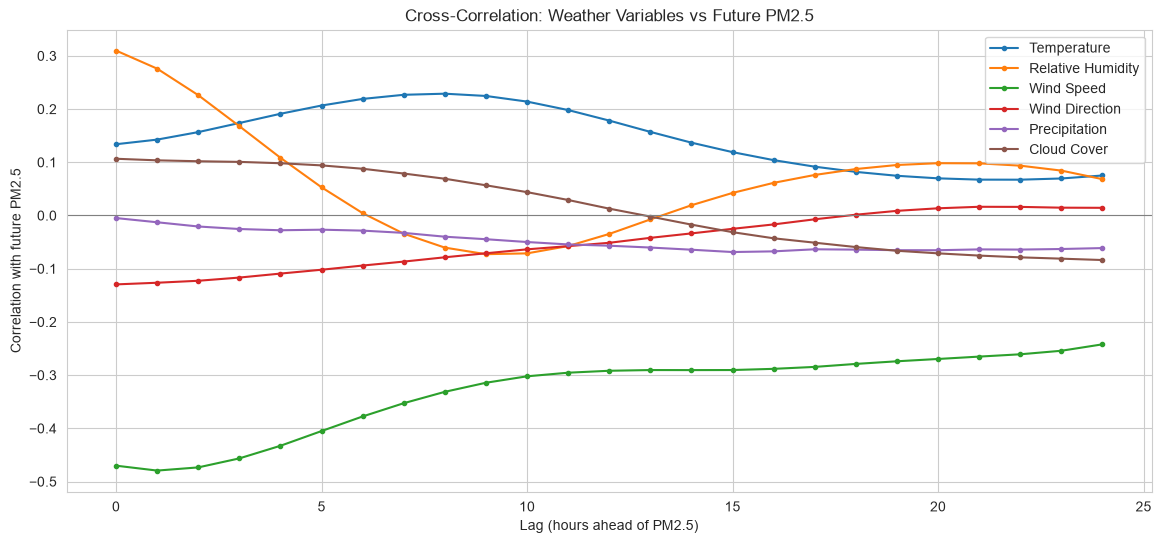

In [8]:
def find_best_lag(df, var, target='PM2.5', max_lag=24):
    results = []
    for lag in range(0, max_lag + 1):
        shifted_target = df[target].shift(-lag)  # PM2.5 'lag' hours in the future
        valid = shifted_target.notna()
        r, _ = pearsonr(df.loc[valid, var], shifted_target[valid])
        results.append({'lag_hours': lag, 'correlation': r})
    return pd.DataFrame(results)

lag_results = {var: find_best_lag(df, var) for var in weather_vars}

fig, ax = plt.subplots(figsize=(14, 6))
for var, res in lag_results.items():
    ax.plot(res['lag_hours'], res['correlation'], marker='o', markersize=3, label=var)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel("Lag (hours ahead of PM2.5)")
ax.set_ylabel("Correlation with future PM2.5")
ax.set_title("Cross-Correlation: Weather Variables vs Future PM2.5")
ax.legend()
plt.show()

In [9]:
best_lags = []
for var, res in lag_results.items():
    best_row = res.loc[res['correlation'].abs().idxmax()]
    best_lags.append({'Variable': var, 'Best Lag (hours)': int(best_row['lag_hours']),
                       'Correlation at Best Lag': round(best_row['correlation'], 4)})

best_lags_df = pd.DataFrame(best_lags).sort_values('Correlation at Best Lag', key=abs, ascending=False)
best_lags_df

,Variable,Best Lag (hours),Correlation at Best Lag
2,Wind Speed,1,-0.4794
1,Relative Humidity,0,0.3098
0,Temperature,8,0.2288
3,Wind Direction,0,-0.1295
5,Cloud Cover,0,0.1066
4,Precipitation,15,-0.0687


**Observation:** _(fill this in after running the cells above)_
Note each variable's best lag. A best lag of 0 means "current conditions
matter most"; a lag of, say, 3–6 hours suggests a delayed effect worth
encoding as a lag feature in Notebook 5 (e.g. `Wind Speed(t-3)`, matching
the pattern already planned there).

## 8. Granger causality — does the past of X help predict PM2.5?

Granger causality tests whether past values of a variable improve prediction
of PM2.5, beyond what PM2.5's own past values already provide. This is
stricter than correlation — it directly asks the modeling-relevant question:
**"is this variable's history worth including as a feature?"**

We test at a lag of up to 6 hours for each weather variable, addressing
these specific questions from the project plan:
- Does humidity improve forecasting?
- Does wind speed improve forecasting?
- Does precipitation improve forecasting?

**Null hypothesis (H0):** the variable does **not** Granger-cause PM2.5.
p-value < 0.05 → reject H0 → the variable **does** help predict PM2.5.

In [10]:
granger_vars = ['Relative Humidity', 'Wind Speed', 'Precipitation', 'Temperature', 'Cloud Cover', 'Wind Direction']
max_lag = 6

granger_summary = []
for var in granger_vars:
    test_data = df[['PM2.5', var]].dropna()
    try:
        result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
        # Take the p-value from the F-test at each lag, keep the best (smallest)
        p_values = [result[lag][0]['ssr_ftest'][1] for lag in range(1, max_lag + 1)]
        best_lag = int(np.argmin(p_values)) + 1
        best_p = min(p_values)
        granger_summary.append({
            'Variable': var,
            'Best Lag (hours)': best_lag,
            'Best p-value': round(best_p, 6),
            'Granger-causes PM2.5?': 'Yes' if best_p < 0.05 else 'No'
        })
    except Exception as e:
        granger_summary.append({'Variable': var, 'Best Lag (hours)': None,
                                 'Best p-value': None, 'Granger-causes PM2.5?': f'Error: {e}'})

granger_df = pd.DataFrame(granger_summary)
granger_df

c:\Users\pc\Desktop\AirSenseAI\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\pc\Desktop\AirSenseAI\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\pc\Desktop\AirSenseAI\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\pc\Desktop\AirSenseAI\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\pc\Desktop\AirSenseAI\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\pc\Desktop\AirSenseAI\.venv\Lib\site-packages\statsmodels\tsa\stat

,Variable,Best Lag (hours),Best p-value,Granger-causes PM2.5?
0,Relative Humidity,2,0.000000,Yes
1,Wind Speed,3,0.000000,Yes
2,Precipitation,1,0.000125,Yes
3,Temperature,6,0.000000,Yes
4,Cloud Cover,2,0.009407,Yes
5,Wind Direction,3,0.023499,Yes


**Observation:** _(fill this in after running the cell above)_
This directly answers the project's key statistical questions. Note which
variables came back "Yes" — those are statistically justified to carry
forward into Feature Engineering. Any "No" results are candidates to exclude,
even if they showed some correlation earlier — Granger causality is the
stricter, more decision-relevant test.

## 9. Final variable shortlist

Combining all four tests, decide which weather variables continue to
Notebook 5. A variable earns inclusion if it shows both a meaningful
correlation (Pearson or Spearman) **and** passes the Granger causality test.

In [11]:
shortlist = combined.merge(granger_df, on='Variable', how='left')
shortlist['Recommended'] = shortlist.apply(
    lambda row: 'Include' if (abs(row['Pearson r']) > 0.1 or abs(row['Spearman rho']) > 0.1)
                and row.get('Granger-causes PM2.5?') == 'Yes'
    else 'Review / Exclude',
    axis=1
)
shortlist[['Variable', 'Pearson r', 'Spearman rho', 'Granger-causes PM2.5?', 'Recommended']]

,Variable,Pearson r,Spearman rho,Granger-causes PM2.5?,Recommended
0,Wind Speed,-0.4702,-0.5358,Yes,Include
1,Relative Humidity,0.3098,0.3467,Yes,Include
2,Temperature,0.1339,0.2080,Yes,Include
3,Wind Direction,-0.1295,-0.2117,Yes,Include
4,Cloud Cover,0.1066,0.1362,Yes,Include
5,Precipitation,-0.0049,0.0250,Yes,Review / Exclude


**Note:** the `abs(...) > 0.1` threshold here is a reasonable starting
point, not a hard rule — adjust it based on your own judgment and what you
observed in Notebook 3's visualizations. Variables marked "Review / Exclude"
aren't necessarily useless (e.g. Wind Direction might matter combined with
Wind Speed, even if weak alone) — use this table as a guide, not gospel, when
building Notebook 5's feature set.

## 10. Summary

Through formal statistical testing we've established:

- ✅ Pearson and Spearman correlation of each weather variable with PM2.5
- ✅ PM2.5 stationarity confirmed via ADF test (informs SARIMA setup later)
- ✅ Optimal lag for each weather variable via cross-correlation
- ✅ Granger causality results answering whether humidity, wind speed, and
  precipitation genuinely help forecast PM2.5
- ✅ A recommended variable shortlist combining all four tests

**Next step → Notebook 5 (Feature Engineering):**
Build lag features for PM2.5 and the shortlisted weather variables (using
the optimal lags found here), rolling statistics, calendar features, and
normalize everything with `MinMaxScaler` before saving `scaler.pkl` and
`feature_columns.pkl`.